In [1]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt

In [2]:
# Load data hasil klastering & target
X_train = pd.read_csv('../dataset/processed/X_train_clustered.csv')
X_test = pd.read_csv('../dataset/processed/X_test_clustered.csv')
y_train = pd.read_csv('../dataset/processed/y_train.csv')['target']
y_test = pd.read_csv('../dataset/processed/y_test.csv')['target']

print(f"Bentuk data awal: X_train {X_train.shape}, X_test {X_test.shape}")

Bentuk data awal: X_train (519, 31), X_test (130, 31)


In [3]:
# Pisahkan kolom kategorikal dan numerik
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
# Pastikan lifestyle_cluster diperlakukan sebagai kategori, bukan angka matematis
cat_cols.append('lifestyle_cluster') 
num_cols = X_train.select_dtypes(exclude=['object']).columns.drop('lifestyle_cluster', errors='ignore').tolist()

# Inisialisasi OneHotEncoder (handle_unknown='ignore' mencegah error jika ada data baru di web)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & Transform pada data Training, HANYA Transform pada data Testing
X_train_cat_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_cat_encoded = encoder.transform(X_test[cat_cols])

# nama kolom baru setelah encoding
encoded_cols = encoder.get_feature_names_out(cat_cols)

# Gabungkan kembali data numerik dengan data kategorikal yang sudah di-encode
X_train_encoded = pd.DataFrame(X_train_cat_encoded, columns=encoded_cols, index=X_train.index)
X_train_encoded[num_cols] = X_train[num_cols]

X_test_encoded = pd.DataFrame(X_test_cat_encoded, columns=encoded_cols, index=X_test.index)
X_test_encoded[num_cols] = X_test[num_cols]

# Simpan objek Encoder
with open('../model/encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print(f"Bentuk data setelah Encoding: {X_train_encoded.shape}")
print("[INFO] Encoder berhasil disimpan ke ../model/encoder.pkl")

Bentuk data setelah Encoding: (519, 59)
[INFO] Encoder berhasil disimpan ke ../model/encoder.pkl


For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [4]:
# 1. Terapkan SMOTE (HANYA pada data Training)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train)

print(f"Distribusi kelas sebelum SMOTE:\n{y_train.value_counts()}")
print(f"Distribusi kelas setelah SMOTE:\n{y_train_balanced.value_counts()}")

# 2. Latih Model Advanced (XGBoost)
# Menambahkan parameter yang aman untuk mencegah overfitting
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

# Simpan Model XGBoost
with open('../model/classifier_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
    
print("\n[INFO] Model XGBoost berhasil dilatih dan disimpan ke ../model/classifier_model.pkl")

Distribusi kelas sebelum SMOTE:
target
0    439
1     80
Name: count, dtype: int64
Distribusi kelas setelah SMOTE:
target
0    439
1    439
Name: count, dtype: int64

[INFO] Model XGBoost berhasil dilatih dan disimpan ke ../model/classifier_model.pkl


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    0 (Aman)       0.86      0.93      0.89       110
1 (Berisiko)       0.27      0.15      0.19        20

    accuracy                           0.81       130
   macro avg       0.56      0.54      0.54       130
weighted avg       0.77      0.81      0.78       130



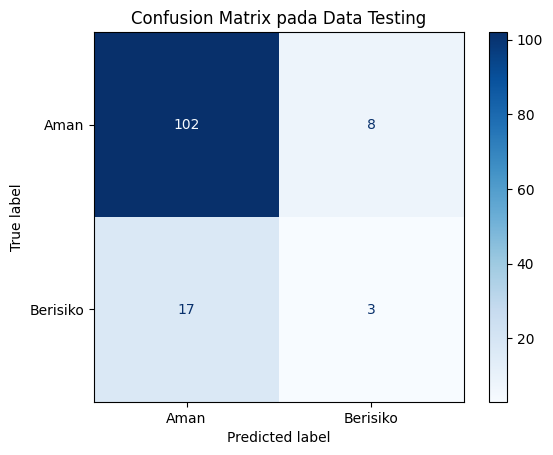

In [5]:
# Prediksi data uji
y_pred = xgb_model.predict(X_test_encoded)

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['0 (Aman)', '1 (Berisiko)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aman', 'Berisiko'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix pada Data Testing')
plt.show()

recall kelas 1 berisiko kurang dari 0.6, sehingga perlu penanganan.
yaitu melakukan optimasi tingkat lanjut yang disebut Cost-Sensitive Learning dan Threshold Moving.  akan dilakukan dua modifikasi:

Penalti Kesalahan (scale_pos_weight): Memaksa model memberikan hukuman yang jauh lebih berat jika dia salah menebak siswa yang berisiko.

Menurunkan Standar Kecurigaan (Custom Threshold): Guru BK lebih baik menegur 10 anak yang ternyata aman (False Positive) daripada membiarkan 1 anak benar-benar gagal tanpa ketahuan (False Negative). Kita akan menurunkan ambang batas kecurigaan model menjadi misal 0.3 (30%).

In [ ]:
# Hitung rasio ketidakseimbangan kelas untuk memberi tahu XGBoost agar lebih sensitif
# Rumus standard: jumlah kelas mayoritas / jumlah kelas minoritas
rasio_kelas = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Latih Model Advanced (XGBoost) dengan Parameter Sensitif
xgb_model = xgb.XGBClassifier(
    n_estimators=200,           # Jumlah pohon diperbanyak
    max_depth=5,                # Pohon sedikit lebih dalam untuk mencari pola tersembunyi
    learning_rate=0.05,         # Belajar lebih lambat agar tidak overfit
    scale_pos_weight=rasio_kelas, # PAKSA model lebih memperhatikan anak berisiko!
    random_state=42,
    eval_metric='logloss'
)

# menggunakan X_train_balanced hasil SMOTE sebelumnya
xgb_model.fit(X_train_balanced, y_train_balanced)

# Simpan Model XGBoost
with open('../model/classifier_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
    
print("\n[INFO] Model XGBoost (Optimized) berhasil dilatih dan disimpan ke ../model/classifier_model.pkl")


[INFO] Model XGBoost (Optimized) berhasil dilatih dan disimpan ke ../model/classifier_model.pkl


In [8]:
rasio_kelas

5.4875

--- CLASSIFICATION REPORT (Optimized Threshold: 0.30) ---
              precision    recall  f1-score   support

    0 (Aman)       0.91      0.88      0.89       110
1 (Berisiko)       0.43      0.50      0.47        20

    accuracy                           0.82       130
   macro avg       0.67      0.69      0.68       130
weighted avg       0.83      0.82      0.83       130



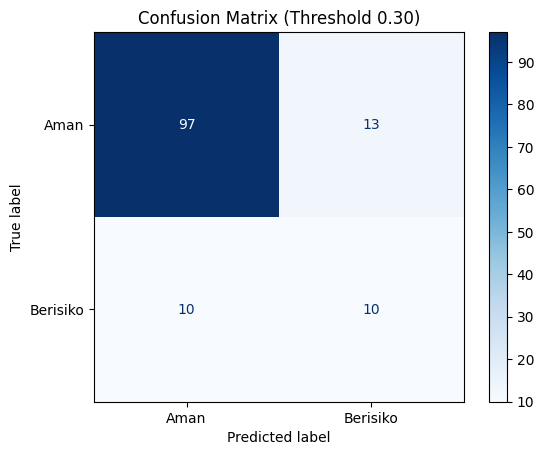

In [ ]:
# 1. Alih-alih langsung predict(), minta probabilitas (keyakinan) model
y_pred_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

# 2. THRESHOLD MOVING (Turunkan ambang batas kecurigaan model)
# Model hanya butuh yakin 30% untuk melabeli siswa "Berisiko"
custom_threshold = 0.30
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print("--- CLASSIFICATION REPORT (Optimized Threshold: 0.30) ---")
print(classification_report(y_test, y_pred_custom, target_names=['0 (Aman)', '1 (Berisiko)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aman', 'Berisiko'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Threshold 0.30)')
plt.show()

[14:56:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


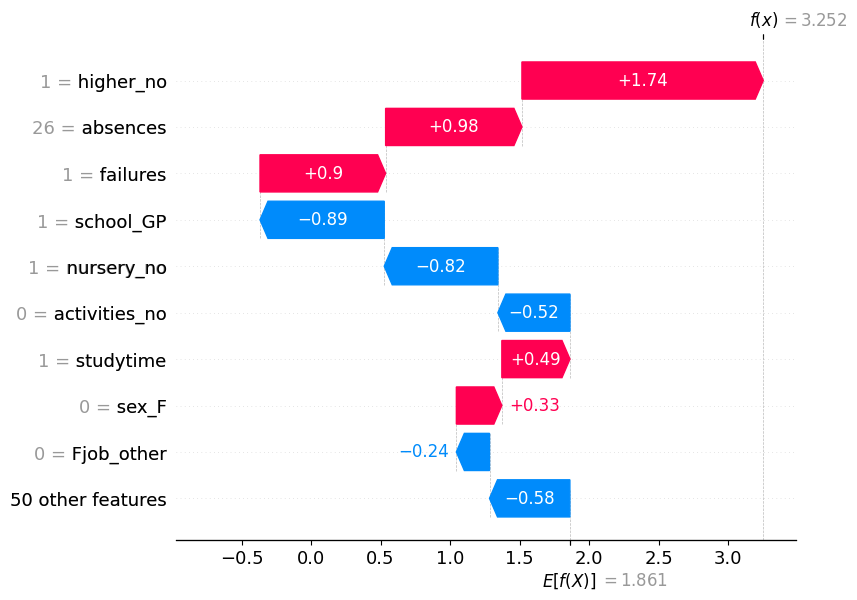

In [18]:
# Inisialisasi SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_encoded)

# Ambil satu contoh siswa secara acak yang diprediksi berisiko gagal (Kelas 1)
# Mencari indeks siswa yang di dunia nyata berisiko, dan ditebak berisiko oleh model
berisiko_indices = y_test[(y_test == 1) & (y_pred == 1)].index

if len(berisiko_indices) > 0:
    sample_idx = berisiko_indices[0] # Ambil siswa pertama dari daftar
    
    # Menemukan posisi indeks relatif di dalam X_test_encoded
    posisi_relatif = X_test_encoded.index.get_loc(sample_idx)

    # Plot SHAP Waterfall untuk siswa spesifik tersebut
    shap.plots.waterfall(shap_values[posisi_relatif])
else:
    print("Tidak ada sampel True Positive untuk divisualisasikan.")

Sistem mengklasifikasikan siswa ini ke dalam kategori Risiko Tinggi. Meskipun siswa ini aktif dalam kegiatan ekstrakurikuler (biru), terdapat masalah motivasi yang sangat mendasar: ia tidak memiliki niat untuk kuliah, sering membolos (26 absen), dan memiliki riwayat gagal sebelumnya. Guru BK disarankan untuk tidak fokus pada nilai akademisnya terlebih dahulu, melainkan melakukan intervensi terkait motivasi masa depan (higher education) dan kedisiplinan kehadiran.